In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

In [2]:
from google.colab import files

uploaded = files.upload()

Saving DEFORESTATION DETECTION.zip to DEFORESTATION DETECTION.zip


In [3]:
zip_path = list(uploaded.keys())[0]

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")

Dataset extracted successfully


In [4]:
for root, dirs, files in os.walk(extract_path):
    print("ROOT:", root)
    print("DIRS:", dirs)
    print("FILES:", len(files))
    print("-"*40)

ROOT: /content/dataset
DIRS: ['DEFORESTATION DETECTION']
FILES: 0
----------------------------------------
ROOT: /content/dataset/DEFORESTATION DETECTION
DIRS: ['deforestation', 'no_deforestation']
FILES: 0
----------------------------------------
ROOT: /content/dataset/DEFORESTATION DETECTION/deforestation
DIRS: []
FILES: 5277
----------------------------------------
ROOT: /content/dataset/DEFORESTATION DETECTION/no_deforestation
DIRS: []
FILES: 9762
----------------------------------------


In [8]:
base_path = "/content/dataset/DEFORESTATION DETECTION"


In [6]:
IMG_SIZE = (128,128)
BATCH_SIZE = 32

In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print("Classes:", class_names)

Found 15039 files belonging to 2 classes.
Using 12032 files for training.
Found 15039 files belonging to 2 classes.
Using 3007 files for validation.
Classes: ['deforestation', 'no_deforestation']


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

In [11]:
labels = []

for _, y in train_ds:
    labels.extend(y.numpy())

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.4299976230092704), 1: np.float64(0.768817891373802)}


In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.3),

    layers.RandomContrast(0.3)
])

In [13]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
model = tf.keras.Sequential([
    layers.Rescaling(1./255),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(2, activation='softmax')
])

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [17]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 247s 637ms/step - accuracy: 0.6187 - loss: 0.6620 - val_accuracy: 0.6791 - val_loss: 0.5471
Epoch 2/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 253s 613ms/step - accuracy: 0.6575 - loss: 0.5714 - val_accuracy: 0.6787 - val_loss: 0.5501
Epoch 3/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 261s 610ms/step - accuracy: 0.6612 - loss: 0.5478 - val_accuracy: 0.6807 - val_loss: 0.5160
Epoch 4/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 263s 612ms/step - accuracy: 0.6633 - loss: 0.5352 - val_accuracy: 0.6854 - val_loss: 0.5047
Epoch 5/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 260s 606ms/step - accuracy: 0.6661 - loss: 0.5292 - val_accuracy: 0.6867 - val_loss: 0.4944
Epoch 6/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 270s 628ms/step - accuracy: 0.6686 - loss: 0.5244 - val_accuracy: 0.6827 - val_loss: 0.4953
Epoch 7/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 257s 615ms/step - accuracy: 0.6678 - loss: 0.5192 - val_accuracy: 0.6871 - val_loss: 0.4881
Epoch 8/20
376/376 ━━━━━━━━━━━━━━━━━━━━ 268s 631ms/step - accuracy: 0.6705 -

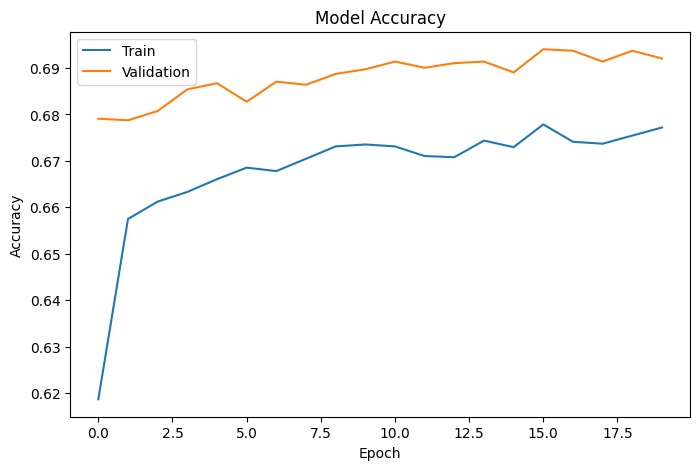

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

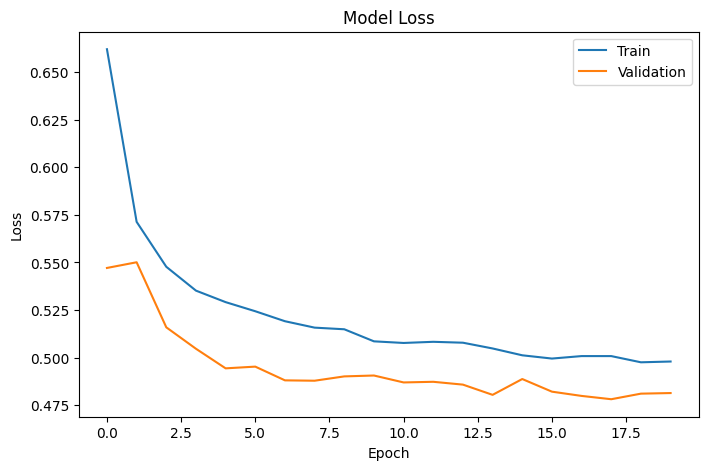

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [20]:
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

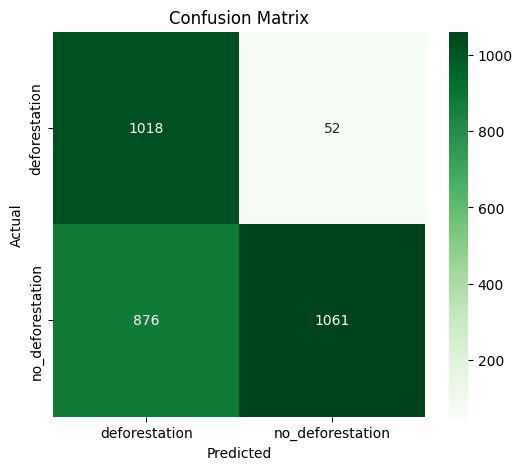

In [21]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [22]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                  precision    recall  f1-score   support

   deforestation       0.54      0.95      0.69      1070
no_deforestation       0.95      0.55      0.70      1937

        accuracy                           0.69      3007
       macro avg       0.75      0.75      0.69      3007
    weighted avg       0.81      0.69      0.69      3007



In [23]:
model.save("deforestation_final_model.h5")

print("Model saved successfully")

Model saved successfully


In [30]:
from google.colab import files

uploaded = files.upload()



Saving Forest_7.jpg to Forest_7.jpg


In [31]:
img_path = list(uploaded.keys())[0]

img = tf.keras.utils.load_img(
    img_path,
    target_size=(128,128)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction) * 100

print("Prediction:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Prediction: no_deforestation
Confidence: 99.27%
